# 📈 주식 예측 시스템 (정리된 버전)

## 목차
1. [환경 설정 및 라이브러리 임포트](#1-환경-설정)
2. [데이터베이스 연결 및 데이터 로드](#2-데이터베이스-연결)
3. [주식 예측 모델 클래스](#3-예측-모델)
4. [모델 학습 및 예측](#4-모델-학습)
5. [결과 시각화 및 분석](#5-시각화-분석)
6. [투자 의사결정 지원](#6-투자-의사결정)

---


## 1. 환경 설정 및 라이브러리 임포트


In [4]:
import pandas as pd

# 출력 행(rows) 제한 해제
pd.set_option('display.max_rows', None)

# 출력 열(columns) 제한 해제
pd.set_option('display.max_columns', None)

# 열 너비 제한 해제 (내용이 잘리지 않도록)
pd.set_option('display.width', 1000)

In [5]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import datetime as dt
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# 머신러닝 라이브러리
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# 기술분석 라이브러리
import talib as ta

# 데이터베이스 라이브러리
from sqlalchemy import create_engine
import mysql.connector

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 설정
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("✅ 모든 라이브러리가 성공적으로 로드되었습니다.")


✅ 모든 라이브러리가 성공적으로 로드되었습니다.


## 2. 데이터베이스 연결 및 데이터 로드


In [6]:
# 데이터베이스 연결 설정
db_config = {
    'db_name': 'fint',
    'db_id': 'esc-sangyoon',
    'db_pwd': 'teamesc',
    # 'db_host': '221.148.162.13'
    'db_host': 'localhost'
}

db_url = f"mysql+mysqlconnector://{db_config['db_id']}:{db_config['db_pwd']}@{db_config['db_host']}/{db_config['db_name']}"
engine = create_engine(db_url)

def load_data_from_db(engine, table_name, query=None):
    """데이터베이스에서 데이터 로드"""
    try:
        if query:
            df = pd.read_sql(sql=query, con=engine)
        else:
            df = pd.read_sql_table(table_name=table_name, con=engine)
        print(f"✅ '{table_name}' 데이터 로드 완료: {df.shape}")
        return df
    except Exception as e:
        print(f"❌ 데이터 로드 오류: {e}")
        return pd.DataFrame()

# 데이터 로드
print("📊 데이터베이스에서 데이터 로드 중...")
report_df = load_data_from_db(engine, 'report')
stock_df = load_data_from_db(engine, 'stock')

print(f"\n📈 Report 데이터: {report_df.shape}")
print(f"🏢 Stock 데이터: {stock_df.shape}")


📊 데이터베이스에서 데이터 로드 중...
✅ 'report' 데이터 로드 완료: (5694627, 16)
✅ 'stock' 데이터 로드 완료: (712, 9)

📈 Report 데이터: (5694627, 16)
🏢 Stock 데이터: (712, 9)


In [7]:
# 유틸리티 함수들
def get_stock_id(ticker):
    """티커로 stock_id 조회"""
    return stock_df[stock_df['ticker'] == ticker]['stock_id'].values[0]

def get_stock_data(ticker):
    """특정 티커의 주식 데이터 조회"""
    stock_id = get_stock_id(ticker)
    data = report_df[report_df['stock_id'] == stock_id].copy()
    
    # 컬럼명 정리 (SQLAlchemy quoted_name 문제 해결)
    new_columns = []
    for col in data.columns:
        if hasattr(col, 'name'):
            new_columns.append(str(col.name))
        else:
            new_columns.append(str(col))
    data.columns = new_columns
    
    data.volume = data.volume.values.astype(np.float64)
    
    return data

# 테스트
print("🧪 데이터 접근 테스트...")
test_data = get_stock_data('NVDA')
print(f"NVDA 데이터: {test_data.shape}")
print(f"컬럼: {list(test_data.columns)}")
print(f"날짜 범위: {test_data['report_date'].min()} ~ {test_data['report_date'].max()}")


🧪 데이터 접근 테스트...
NVDA 데이터: (6702, 16)
컬럼: ['report_id', 'report_date', 'stock_id', 'open', 'close', 'high', 'low', 'volume', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'atr', 'stoch_k', 'stoch_d', 'obv']
날짜 범위: 1999-01-22 00:00:00 ~ 2025-09-12 00:00:00


In [8]:
!nvidia-smi

Wed Sep 17 19:50:12 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.08                 Driver Version: 581.08         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 Ti   WDDM  |   00000000:01:00.0 Off |                  N/A |
|  0%   41C    P8              9W /  285W |    1263MiB /  12282MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3. 주식 예측 모델 클래스


In [9]:
class StockPredictor:
    """주식 가격 예측 모델"""
    
    def __init__(self, model=None, use_scaler=True, random_state=42):
        self.model = model if model else RandomForestRegressor(
            n_estimators=200, 
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=random_state
        )
        self.use_scaler = use_scaler
        self.scaler = StandardScaler() if use_scaler else None
        self.feature_columns = None
        
    def calculate_technical_indicators(self, df):
        """기술 지표 계산"""
        df_temp = df.copy()
        
        # 기본 지표들
        df_temp['rsi'] = ta.RSI(df_temp['close'].values, timeperiod=14)
        df_temp['macd'], df_temp['macd_signal'], df_temp['macd_hist'] = ta.MACD(
            df_temp['close'].values, fastperiod=12, slowperiod=26, signalperiod=9)
        df_temp['atr'] = ta.ATR(df_temp['high'].values, df_temp['low'].values, 
                               df_temp['close'].values, timeperiod=14)
        df_temp['stoch_k'], df_temp['stoch_d'] = ta.STOCH(
            df_temp['high'].values, df_temp['low'].values, df_temp['close'].values,
            fastk_period=5, slowk_period=3, slowd_period=3)
        df_temp['obv'] = ta.OBV(df_temp['close'].values, df_temp['volume'].values)
        
        return df_temp
    
    def add_engineered_features(self, df):
        """추가 피처 엔지니어링"""
        df_temp = df.copy()
        
        # 이동평균
        for period in [5, 10, 20, 50]:
            df_temp[f'sma_{period}'] = df_temp['close'].rolling(period).mean()
            df_temp[f'price_to_sma_{period}'] = df_temp['close'] / df_temp[f'sma_{period}']
        
        # 볼린저 밴드
        sma_20 = df_temp['close'].rolling(20).mean()
        std_20 = df_temp['close'].rolling(20).std()
        df_temp['bb_upper'] = sma_20 + (std_20 * 2)
        df_temp['bb_lower'] = sma_20 - (std_20 * 2)
        df_temp['bb_position'] = (df_temp['close'] - df_temp['bb_lower']) / (df_temp['bb_upper'] - df_temp['bb_lower'])
        
        # 가격 변화율
        for period in [1, 3, 5, 10]:
            df_temp[f'return_{period}d'] = df_temp['close'].pct_change(period) * 100
        
        # 변동성
        df_temp['volatility_10d'] = df_temp['close'].pct_change().rolling(10).std() * 100
        df_temp['volatility_20d'] = df_temp['close'].pct_change().rolling(20).std() * 100
        
        # 거래량 지표
        df_temp['volume_sma_10'] = df_temp['volume'].rolling(10).mean()
        df_temp['volume_ratio'] = df_temp['volume'] / df_temp['volume_sma_10']
        
        return df_temp
    
    def prepare_features(self, df):
        """피처 준비 및 엔지니어링"""
        df_temp = df.copy()
        
        # 컬럼명을 소문자로 변환
        df_temp.columns = df_temp.columns.str.lower()
        
        print("🔧 기술 지표 계산 중...")
        print(df_temp.columns)
        df_temp = self.calculate_technical_indicators(df_temp)
        print(df_temp.columns)
        
        print("🔧 추가 피처 생성 중...")
        df_temp = self.add_engineered_features(df_temp)
        
        # 타겟 변수 생성 (다음날 수익률)
        df_temp['target'] = (df_temp['close'].shift(-1) / df_temp['close'] - 1) * 100
        
        # NaN 제거
        df_temp = df_temp.dropna()
        
        print(f"✅ 피처 준비 완료: {df_temp.shape}")
        return df_temp
    
    def get_feature_columns(self, df):
        """피처 컬럼 선택"""
        exclude_cols = ['report_id', 'report_date', 'stock_id', 'target']
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        return feature_cols

print("✅ StockPredictor 클래스 정의 완료 (1/2)")


✅ StockPredictor 클래스 정의 완료 (1/2)


In [10]:
# StockPredictor 클래스 계속 (학습 및 예측 메소드)
class StockPredictor(StockPredictor):
    
    def time_series_split_validate(self, X, y, n_splits=5):
        """시계열 교차검증"""
        tscv = TimeSeriesSplit(n_splits=n_splits)
        cv_scores = []
        
        for train_idx, val_idx in tscv.split(X):
            X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
            y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
            
            # 스케일링 (numpy array 사용)
            if self.use_scaler:
                temp_scaler = StandardScaler()
                X_train_scaled = temp_scaler.fit_transform(X_train_cv.values)
                X_val_scaled = temp_scaler.transform(X_val_cv.values)
            else:
                X_train_scaled, X_val_scaled = X_train_cv.values, X_val_cv.values
            
            # 모델 학습 및 예측
            self.model.fit(X_train_scaled, y_train_cv)
            pred = self.model.predict(X_val_scaled)
            
            mse = mean_squared_error(y_val_cv, pred)
            cv_scores.append(mse)
        
        return np.mean(cv_scores), np.std(cv_scores)
    
    def train(self, X_train, y_train):
        """모델 학습"""
        # 피처 컬럼 저장
        self.feature_columns = X_train.columns.tolist()
        
        # 교차검증
        print("🔄 교차검증 수행 중...")
        cv_mean, cv_std = self.time_series_split_validate(X_train, y_train)
        print(f"📊 교차검증 MSE: {cv_mean:.4f} ± {cv_std:.4f}")
        
        # 스케일링
        if self.use_scaler:
            X_train_scaled = self.scaler.fit_transform(X_train.values)
        else:
            X_train_scaled = X_train.values
        
        # 최종 모델 학습
        print("🎯 최종 모델 학습 중...")
        self.model.fit(X_train_scaled, y_train)
        print("✅ 모델 학습 완료")
        
        return self
    
    def predict_next_returns(self, X_last, steps=5):
        """미래 수익률 예측"""
        if self.feature_columns is None:
            raise ValueError("모델이 학습되지 않았습니다.")
        
        predictions = []
        current_features = X_last.copy()
        
        for step in range(steps):
            # 현재 피처로 수익률 예측
            if self.use_scaler:
                features_scaled = self.scaler.transform(current_features[self.feature_columns].values)
            else:
                features_scaled = current_features[self.feature_columns].values
            
            return_pred = self.model.predict(features_scaled)[0]
            predictions.append(return_pred)
            
            # 다음 스텝을 위한 피처 업데이트 (간단한 방식)
            current_features = current_features.copy()
            
        return predictions
    
    def convert_returns_to_prices(self, initial_price, return_predictions):
        """수익률을 가격으로 변환"""
        prices = [initial_price]
        for return_pct in return_predictions:
            next_price = prices[-1] * (1 + return_pct / 100)
            prices.append(next_price)
        return prices[1:]  # 초기 가격 제외

print("✅ StockPredictor 클래스 정의 완료 (2/2)")


✅ StockPredictor 클래스 정의 완료 (2/2)


## 4. 모델 학습 및 예측


In [11]:
def predict_stock(ticker, train_days=500, predict_steps=5, today=None):
    """주식 예측 실행 함수"""
    
    if today is None:
        today = dt.date.today()
    
    print(f"\n🎯 {ticker} 주식 예측 시작")
    print(f"📅 기준일: {today}")
    print(f"📚 학습 기간: {train_days}일")
    print(f"🔮 예측 기간: {predict_steps}일")
    print("-" * 50)
    
    # 1. 데이터 로드
    print("📊 데이터 로드 중...")
    stock_data = get_stock_data(ticker)
    stock_data.set_index('report_date', inplace=True)
    
    # 2. 모델 초기화
    predictor = StockPredictor()
    
    # 3. 피처 준비
    prepared_data = predictor.prepare_features(stock_data)
    print(f"prepared_data : {prepared_data.iloc[-1]}")
    
    # 4. 날짜 필터링
    # TODO : 영업일 기준으로 back, forward 가능하게 수정
    end_date = today + timedelta(days=predict_steps)
    start_date = today - timedelta(days=train_days)
    
    date_mask = (prepared_data.index >= pd.to_datetime(start_date)) & \
                (prepared_data.index <= pd.to_datetime(end_date))
    filtered_data = prepared_data[date_mask]
    
    # 5. 훈련/테스트 분할
    # split_idx = int(len(filtered_data) * 0.8)
    split_idx = int(len(filtered_data) * 1)
    train_data = filtered_data.iloc[:split_idx]
    test_data = filtered_data.iloc[split_idx:]
    
    # 6. 피처와 타겟 분리
    feature_cols = predictor.get_feature_columns(train_data)
    X_train = train_data[feature_cols].copy()
    y_train = train_data['target'].copy()
    
    print(f"📈 학습 데이터: {len(X_train)}개")
    print(f"🔢 피처 수: {len(feature_cols)}개 ", feature_cols)
    
    # 7. 모델 학습
    predictor.train(X_train, y_train)
    
    # 8. 미래 예측
    print("🔮 미래 예측 수행 중...")
    last_features = X_train.iloc[[-1]]
    return_predictions = predictor.predict_next_returns(last_features, predict_steps)
    
    # 9. 수익률을 가격으로 변환
    last_price = train_data['close'].iloc[-1]
    price_predictions = predictor.convert_returns_to_prices(last_price, return_predictions)
    
    # 10. 결과 출력
    print(f"\n📊 {ticker} 예측 결과:")
    print("-" * 30)
    print(f"{X_train.iloc[-1]}")
    print(f"{y_train.iloc[-1]}")
    print(f"🎯 현재가: ${last_price:.2f}")
    for i, (ret, price) in enumerate(zip(return_predictions, price_predictions)):
        change = price - last_price
        print(f"D+{i+1}: ${price:.2f} ({ret:+.2f}%, {change:+.2f})")
    
    total_change = price_predictions[-1] - last_price
    total_change_pct = (total_change / last_price) * 100
    print(f"\n🏁 {predict_steps}일 총 변화: {total_change:+.2f} ({total_change_pct:+.2f}%)")
    
    return {
        'ticker': ticker,
        'current_price': last_price,
        'predictions': price_predictions,
        'returns': return_predictions,
        'model': predictor,
        'data': stock_data,
        'train_data': train_data
    }

print("✅ 예측 함수 정의 완료")


✅ 예측 함수 정의 완료


In [12]:
# NVDA 주식 예측 실행
result = predict_stock(
    ticker='NVDA',
    train_days=500,
    predict_steps=5,
    today=dt.date(2025, 9, 7)
)



🎯 NVDA 주식 예측 시작
📅 기준일: 2025-09-07
📚 학습 기간: 500일
🔮 예측 기간: 5일
--------------------------------------------------
📊 데이터 로드 중...
🔧 기술 지표 계산 중...
Index(['report_id', 'stock_id', 'open', 'close', 'high', 'low', 'volume', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'atr', 'stoch_k', 'stoch_d', 'obv'], dtype='object')
Index(['report_id', 'stock_id', 'open', 'close', 'high', 'low', 'volume', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'atr', 'stoch_k', 'stoch_d', 'obv'], dtype='object')
🔧 추가 피처 생성 중...
✅ 피처 준비 완료: (6652, 35)
prepared_data : report_id          3.800115e+06
stock_id           4.750000e+02
open               1.796800e+02
close              1.771700e+02
high               1.802800e+02
low                1.764800e+02
volume             1.511593e+08
rsi                5.457252e+01
macd              -3.030665e-01
macd_signal        2.187130e-01
macd_hist         -5.217795e-01
atr                5.041320e+00
stoch_k            8.272104e+01
stoch_d            6.870519e+01
obv            

In [15]:
# NVDA 주식 예측 실행
result = predict_stock(
    ticker='NVDA',
    train_days=500,
    predict_steps=5,
    today=dt.date(2025, 9, 10)
)



🎯 NVDA 주식 예측 시작
📅 기준일: 2025-09-10
📚 학습 기간: 500일
🔮 예측 기간: 5일
--------------------------------------------------
📊 데이터 로드 중...
🔧 기술 지표 계산 중...
Index(['report_id', 'stock_id', 'open', 'close', 'high', 'low', 'volume', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'atr', 'stoch_k', 'stoch_d', 'obv'], dtype='object')
Index(['report_id', 'stock_id', 'open', 'close', 'high', 'low', 'volume', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'atr', 'stoch_k', 'stoch_d', 'obv'], dtype='object')
🔧 추가 피처 생성 중...
✅ 피처 준비 완료: (6652, 35)
prepared_data : report_id          3.800115e+06
stock_id           4.750000e+02
open               1.796800e+02
close              1.771700e+02
high               1.802800e+02
low                1.764800e+02
volume             1.511593e+08
rsi                5.457252e+01
macd              -3.030665e-01
macd_signal        2.187130e-01
macd_hist         -5.217795e-01
atr                5.041320e+00
stoch_k            8.272104e+01
stoch_d            6.870519e+01
obv            

## 5. 결과 시각화 및 분석


In [16]:
import matplotlib.pyplot as plt
from matplotlib import rc

# 한글 폰트 설정 (Windows 기준)
rc('font', family='Malgun Gothic')  # 또는 'AppleGothic', 'NanumGothic' 등
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지


📈 NVDA 예측 차트 생성 중...
실제 데이터 범위: $143.84 ~ $183.15
예측 데이터 범위: $177.56 ~ $179.12


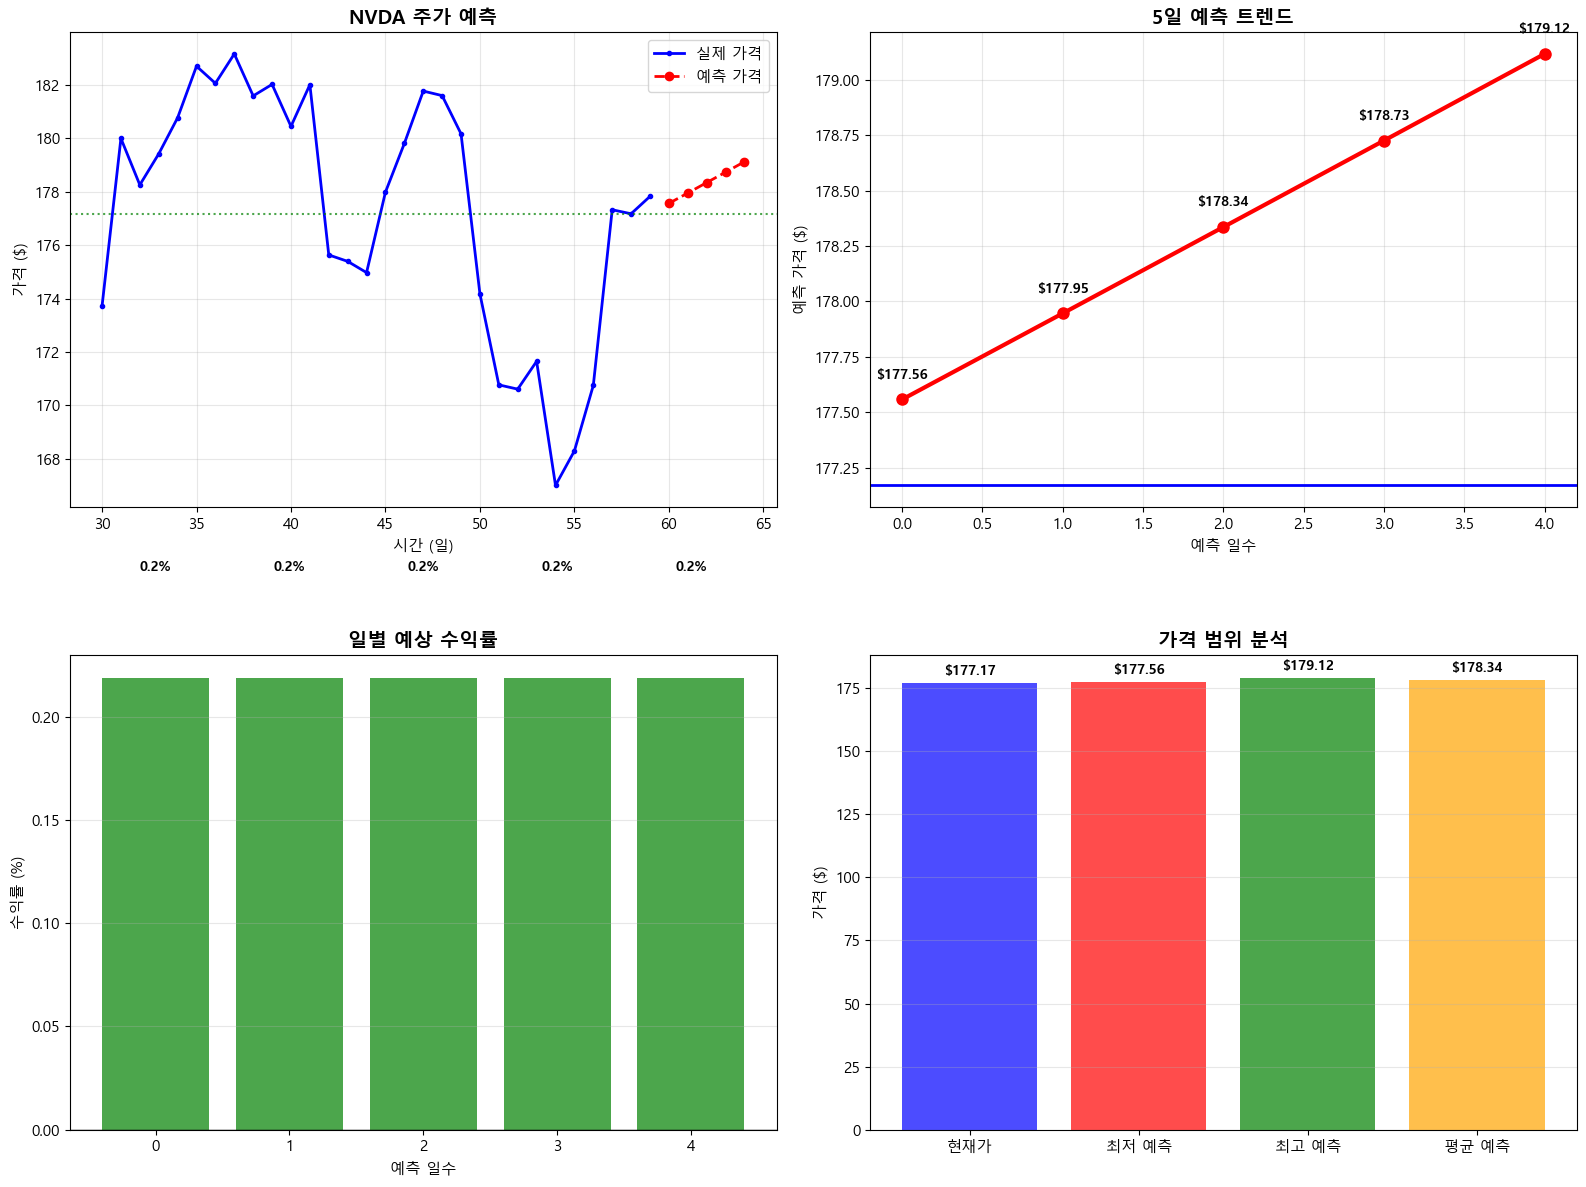


📊 NVDA 분석 요약:
----------------------------------------
🎯 현재가: $177.17
📈 평균 예측가: $178.34
🔺 최고 예측가: $179.12
🔻 최저 예측가: $177.56
🏁 5일 총 변화: +1.95 (+1.10%)
💭 트렌드: 📈 약한 상승 예상


In [17]:
def create_prediction_charts(result):
    """예측 결과 시각화 (문제 해결된 버전)"""
    
    ticker = result['ticker']
    current_price = result['current_price']
    predictions = result['predictions']
    data = result['data']
    
    print(f"📈 {ticker} 예측 차트 생성 중...")
    
    # 데이터 준비
    recent_data = data.tail(60)
    actual_prices = recent_data['close'].astype(float)
    pred_prices = [float(p) for p in predictions]
    
    print(f"실제 데이터 범위: ${actual_prices.min():.2f} ~ ${actual_prices.max():.2f}")
    print(f"예측 데이터 범위: ${min(pred_prices):.2f} ~ ${max(pred_prices):.2f}")
    
    # 차트 생성
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. 가격 예측 차트
    dates_numeric = range(len(actual_prices))
    pred_x = range(len(actual_prices), len(actual_prices) + len(pred_prices))
    
    ax1.plot(dates_numeric[-30:], actual_prices.tail(30), 'b-', 
             label='실제 가격', linewidth=2, marker='.')
    ax1.plot(pred_x, pred_prices, 'r--', 
             label='예측 가격', linewidth=2, marker='o', markersize=6)
    ax1.axhline(y=current_price, color='green', linestyle=':', alpha=0.7)
    ax1.set_title(f'{ticker} 주가 예측', fontsize=14, fontweight='bold')
    ax1.set_xlabel('시간 (일)')
    ax1.set_ylabel('가격 ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. 예측 트렌드
    ax2.plot(range(len(pred_prices)), pred_prices, 'ro-', linewidth=3, markersize=8)
    ax2.axhline(y=current_price, color='blue', linestyle='-', linewidth=2)
    ax2.set_title('5일 예측 트렌드', fontsize=14, fontweight='bold')
    ax2.set_xlabel('예측 일수')
    ax2.set_ylabel('예측 가격 ($)')
    ax2.grid(True, alpha=0.3)
    
    # 예측값 라벨
    for i, price in enumerate(pred_prices):
        ax2.annotate(f'${price:.2f}', (i, price), 
                    xytext=(0, 15), textcoords="offset points", 
                    ha='center', fontweight='bold', fontsize=10)
    
    # 3. 일별 수익률
    daily_returns = []
    temp_price = current_price
    for price in pred_prices:
        ret = (price - temp_price) / temp_price * 100
        daily_returns.append(ret)
        temp_price = price
    
    colors = ['green' if r > 0 else 'red' if r < 0 else 'gray' for r in daily_returns]
    bars = ax3.bar(range(len(daily_returns)), daily_returns, color=colors, alpha=0.7)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax3.set_title('일별 예상 수익률', fontsize=14, fontweight='bold')
    ax3.set_xlabel('예측 일수')
    ax3.set_ylabel('수익률 (%)')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 수익률 라벨
    for i, (bar, ret) in enumerate(zip(bars, daily_returns)):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., 
                height + (0.05 if height >= 0 else -0.1), 
                f'{ret:.1f}%', ha='center', 
                va='bottom' if height >= 0 else 'top', 
                fontweight='bold', fontsize=10)
    
    # 4. 가격 범위 분석
    price_data = [current_price, min(pred_prices), max(pred_prices), np.mean(pred_prices)]
    price_labels = ['현재가', '최저 예측', '최고 예측', '평균 예측']
    price_colors = ['blue', 'red', 'green', 'orange']
    
    bars = ax4.bar(price_labels, price_data, color=price_colors, alpha=0.7)
    ax4.set_title('가격 범위 분석', fontsize=14, fontweight='bold')
    ax4.set_ylabel('가격 ($)')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # 가격 라벨
    for bar, price in zip(bars, price_data):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + height*0.01, 
                f'${price:.2f}', ha='center', va='bottom', 
                fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # 요약 정보
    print(f"\n📊 {ticker} 분석 요약:")
    print("-" * 40)
    print(f"🎯 현재가: ${current_price:.2f}")
    print(f"📈 평균 예측가: ${np.mean(pred_prices):.2f}")
    print(f"🔺 최고 예측가: ${max(pred_prices):.2f}")
    print(f"🔻 최저 예측가: ${min(pred_prices):.2f}")
    
    total_change = pred_prices[-1] - current_price
    total_change_pct = (total_change / current_price) * 100
    print(f"🏁 5일 총 변화: {total_change:+.2f} ({total_change_pct:+.2f}%)")
    
    if total_change_pct > 2:
        trend = "🚀 강한 상승 예상"
    elif total_change_pct > 0:
        trend = "📈 약한 상승 예상"
    elif total_change_pct > -2:
        trend = "➡️ 횡보 예상"
    else:
        trend = "📉 하락 예상"
    
    print(f"💭 트렌드: {trend}")

# 차트 생성
create_prediction_charts(result)


## 6. 투자 의사결정 지원


In [18]:
class InvestmentAnalyzer:
    """투자 의사결정 분석 클래스"""
    
    def __init__(self, result):
        self.result = result
        self.ticker = result['ticker']
        self.current_price = result['current_price']
        self.predictions = result['predictions']
        self.data = result['data']
    
    def calculate_metrics(self):
        """주요 지표 계산"""
        pred_avg = np.mean(self.predictions)
        pred_max = max(self.predictions)
        pred_min = min(self.predictions)
        
        total_return = (self.predictions[-1] - self.current_price) / self.current_price * 100
        avg_daily_return = np.mean([(pred - self.current_price) / self.current_price * 100 
                                   for pred in self.predictions])
        volatility = np.std(self.predictions)
        upside_prob = sum(1 for pred in self.predictions if pred > self.current_price) / len(self.predictions) * 100
        
        return {
            '현재가': self.current_price,
            '예측_평균가': pred_avg,
            '예측_최고가': pred_max,
            '예측_최저가': pred_min,
            '예상_총수익률': total_return,
            '예상_일평균수익률': avg_daily_return,
            '예측_변동성': volatility,
            '상승_확률': upside_prob
        }
    
    def risk_analysis(self):
        """리스크 분석"""
        returns = self.data['close'].pct_change().dropna()
        
        # 예측 수익률 계산
        pred_returns = []
        current_price = self.current_price
        for pred_price in self.predictions:
            ret = (pred_price - current_price) / current_price
            pred_returns.append(ret)
            current_price = pred_price
        
        risk_metrics = {
            '과거_변동성_연율화': returns.std() * np.sqrt(252) * 100,
            '예측_변동성': np.std(pred_returns) * 100,
            'VaR_95': np.percentile(pred_returns, 5) * 100,
            '최대_예상손실': min(pred_returns) * 100,
            '최대_예상수익': max(pred_returns) * 100,
            '샤프비율_추정': (np.mean(pred_returns) / np.std(pred_returns)) if np.std(pred_returns) > 0 else 0
        }
        
        return risk_metrics
    
    def generate_recommendation(self):
        """투자 추천 생성"""
        metrics = self.calculate_metrics()
        risk_metrics = self.risk_analysis()
        
        score = 0
        signals = []
        
        # 수익률 평가
        expected_return = metrics['예상_총수익률']
        if expected_return > 5:
            signals.append("✅ 높은 수익률 기대 (+5% 이상)")
            score += 2
        elif expected_return > 2:
            signals.append("🟡 보통 수익률 기대 (2-5%)")
            score += 1
        else:
            signals.append("🔴 낮은 수익률 기대 (2% 미만)")
            score -= 1
        
        # 상승 확률 평가
        upside_prob = metrics['상승_확률']
        if upside_prob > 70:
            signals.append("✅ 높은 상승 확률 (70% 이상)")
            score += 2
        elif upside_prob > 50:
            signals.append("🟡 보통 상승 확률 (50-70%)")
            score += 1
        else:
            signals.append("🔴 낮은 상승 확률 (50% 미만)")
            score -= 1
        
        # VaR 평가
        var_95 = risk_metrics['VaR_95']
        if var_95 > -3:
            signals.append("✅ 낮은 리스크 (VaR -3% 이상)")
            score += 1
        elif var_95 > -5:
            signals.append("🟡 보통 리스크 (VaR -3% ~ -5%)")
        else:
            signals.append("🔴 높은 리스크 (VaR -5% 미만)")
            score -= 1
        
        # 최종 추천
        if score >= 4:
            recommendation = "🚀 강력 매수 추천"
            action = "BUY"
        elif score >= 2:
            recommendation = "📈 매수 추천"
            action = "BUY"
        elif score >= 0:
            recommendation = "⏸️ 관망 추천"
            action = "HOLD"
        else:
            recommendation = "📉 매도 고려"
            action = "SELL"
        
        return {
            'recommendation': recommendation,
            'action': action,
            'score': score,
            'max_score': 5,
            'signals': signals,
            'metrics': metrics,
            'risk_metrics': risk_metrics
        }
    
    def print_analysis(self):
        """분석 결과 출력"""
        analysis = self.generate_recommendation()
        
        print(f"\n💼 {self.ticker} 투자 의사결정 분석")
        print("=" * 50)
        
        # 추천 결과
        print(f"\n🎯 투자 추천: {analysis['recommendation']}")
        print(f"📊 액션: {analysis['action']}")
        print(f"⭐ 신뢰도: {analysis['score']}/{analysis['max_score']}")
        
        # 주요 지표
        metrics = analysis['metrics']
        print(f"\n📋 주요 지표:")
        print(f"  현재가: ${metrics['현재가']:.2f}")
        print(f"  예측 평균가: ${metrics['예측_평균가']:.2f}")
        print(f"  기대 수익률: {metrics['예상_총수익률']:.2f}%")
        print(f"  상승 확률: {metrics['상승_확률']:.1f}%")
        
        # 리스크 지표
        risk_metrics = analysis['risk_metrics']
        print(f"\n⚠️ 리스크 분석:")
        print(f"  VaR (95%): {risk_metrics['VaR_95']:.2f}%")
        print(f"  예측 변동성: {risk_metrics['예측_변동성']:.2f}%")
        print(f"  샤프 비율: {risk_metrics['샤프비율_추정']:.2f}")
        
        # 근거
        print(f"\n🔍 분석 근거:")
        for signal in analysis['signals']:
            print(f"  {signal}")
        
        return analysis

# 투자 분석 실행
analyzer = InvestmentAnalyzer(result)
investment_analysis = analyzer.print_analysis()



💼 NVDA 투자 의사결정 분석

🎯 투자 추천: 📈 매수 추천
📊 액션: BUY
⭐ 신뢰도: 2/5

📋 주요 지표:
  현재가: $177.17
  예측 평균가: $178.34
  기대 수익률: 1.10%
  상승 확률: 100.0%

⚠️ 리스크 분석:
  VaR (95%): 0.22%
  예측 변동성: 0.00%
  샤프 비율: 47133949667271.02

🔍 분석 근거:
  🔴 낮은 수익률 기대 (2% 미만)
  ✅ 높은 상승 확률 (70% 이상)
  ✅ 낮은 리스크 (VaR -3% 이상)



🎯 XRAY 주식 예측 시작
📅 기준일: 2025-09-07
📚 학습 기간: 500일
🔮 예측 기간: 5일
--------------------------------------------------
📊 데이터 로드 중...
🔧 기술 지표 계산 중...
Index(['report_id', 'stock_id', 'open', 'close', 'high', 'low', 'volume', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'atr', 'stoch_k', 'stoch_d', 'obv'], dtype='object')
Index(['report_id', 'stock_id', 'open', 'close', 'high', 'low', 'volume', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'atr', 'stoch_k', 'stoch_d', 'obv'], dtype='object')
🔧 추가 피처 생성 중...
✅ 피처 준비 완료: (9545, 35)
prepared_data : report_id          5.638763e+06
stock_id           7.050000e+02
open               1.365000e+01
close              1.394000e+01
high               1.401000e+01
low                1.362000e+01
volume             1.995200e+06
rsi                4.548893e+01
macd              -1.629655e-01
macd_signal       -1.835950e-01
macd_hist          2.062953e-02
atr                4.874609e-01
stoch_k            1.496420e+01
stoch_d            2.811520e+01
obv            

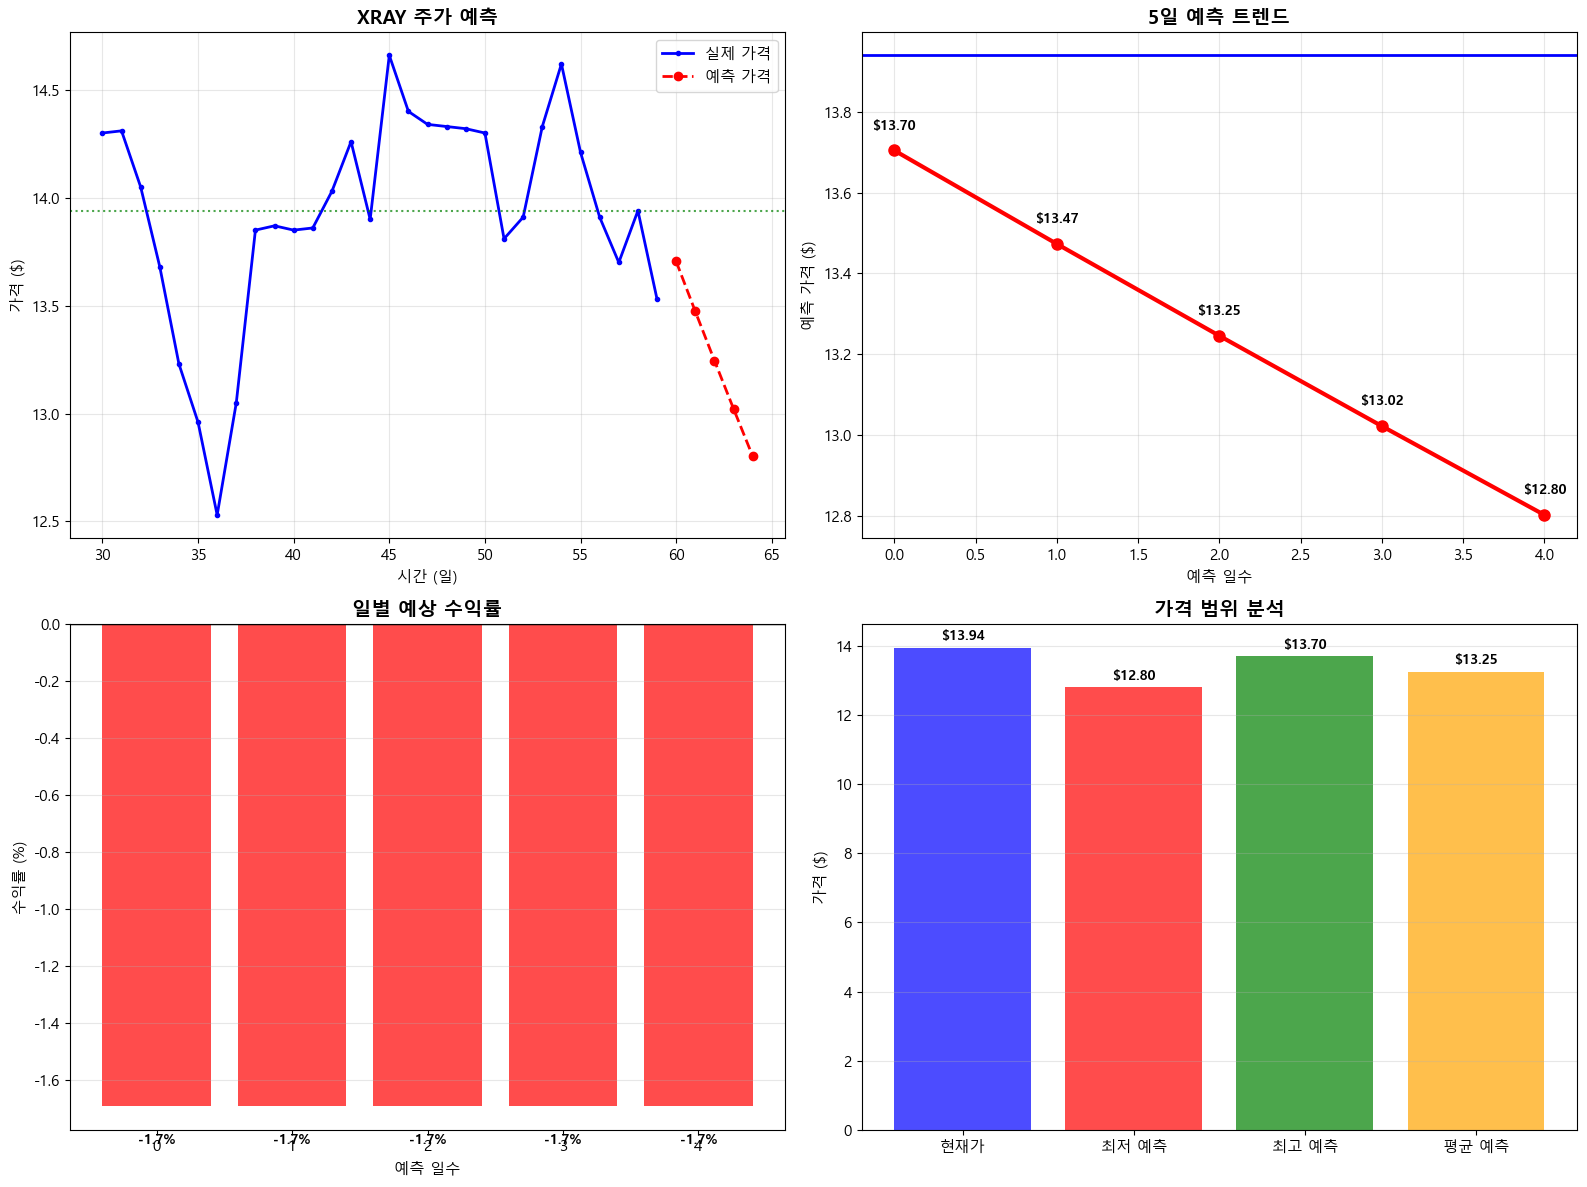


📊 XRAY 분석 요약:
----------------------------------------
🎯 현재가: $13.94
📈 평균 예측가: $13.25
🔺 최고 예측가: $13.70
🔻 최저 예측가: $12.80
🏁 5일 총 변화: -1.14 (-8.16%)
💭 트렌드: 📉 하락 예상

💼 XRAY 투자 의사결정 분석

🎯 투자 추천: 📉 매도 고려
📊 액션: SELL
⭐ 신뢰도: -1/5

📋 주요 지표:
  현재가: $13.94
  예측 평균가: $13.25
  기대 수익률: -8.16%
  상승 확률: 0.0%

⚠️ 리스크 분석:
  VaR (95%): -1.69%
  예측 변동성: 0.00%
  샤프 비율: -885552448188784.75

🔍 분석 근거:
  🔴 낮은 수익률 기대 (2% 미만)
  🔴 낮은 상승 확률 (50% 미만)
  ✅ 낮은 리스크 (VaR -3% 이상)


In [20]:
# 주식 예측 실행
result = predict_stock(
    ticker='XRAY',
    train_days=500,
    predict_steps=5,
    today=dt.date(2025, 9, 7)
)


# 차트 생성
create_prediction_charts(result)


# 투자 분석 실행
analyzer = InvestmentAnalyzer(result)
investment_analysis = analyzer.print_analysis()